# Part 2.4 — NeRF Network

## Architecture

### Position branch
- Input: **3D world coordinates** `(x, y, z)`
- Apply **positional encoding** with `L_xyz = 10`
- Pass through **8 fully connected layers** of width **256**
- Add a **skip connection** by concatenating the encoded xyz input back into the network **after the 4th layer**

### Density head
- From the shared trunk, predict **density** `sigma`
- Use **ReLU** on sigma so density stays non-negative

### Color branch
- From the shared trunk, first create a **256-d feature vector**
- Input: **ray direction** `r_d`
- Apply **positional encoding** with `L_dir = 4`
- Concatenate the feature vector with the encoded ray direction
- Pass through:
  - `Linear(128)` + `ReLU`
  - `Linear(3)` + `Sigmoid`
- Output is **RGB in [0, 1]**

In [2]:
import os
import sys
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

project_root = Path("/content/drive/MyDrive/Spring 2026/Computer Vision/HW4")
data_path = project_root / "data" / "lego_200x200.npz"
output_dir = project_root / "output" / "part3"

os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

output_dir.mkdir(parents=True, exist_ok=True)

print("Working directory:", Path.cwd())
print("Data path exists:", data_path.exists())
print("Data path:", data_path)
print("Output dir:", output_dir)

Mounted at /content/drive
Working directory: /content/drive/MyDrive/Spring 2026/Computer Vision/HW4
Data path exists: True
Data path: /content/drive/MyDrive/Spring 2026/Computer Vision/HW4/data/lego_200x200.npz
Output dir: /content/drive/MyDrive/Spring 2026/Computer Vision/HW4/output/part3


In [3]:
import os
import sys
from pathlib import Path

print("Current working directory:", Path.cwd())
print("Files here:", os.listdir())

Current working directory: /content/drive/MyDrive/Spring 2026/Computer Vision/HW4
Files here: ['output', 'data', 'src']


In [4]:
import os
import sys
from pathlib import Path

project_root = Path("/content/drive/MyDrive/Spring 2026/Computer Vision/HW4")
src_path = project_root / "src"

os.chdir(project_root)

sys.path = [p for p in sys.path if "Spring 2026/Computer Vision/HW4" not in p]
sys.path.insert(0, str(project_root))

print("cwd:", Path.cwd())
print("project_root:", project_root.exists())
print("src_path:", src_path.exists())
print("__init__:", (src_path / "__init__.py").exists())
print("dataset_3d:", (src_path / "dataset_3d.py").exists())
print("rendering:", (src_path / "rendering.py").exists())
print("sys.path[:3]:", sys.path[:3])

cwd: /content/drive/MyDrive/Spring 2026/Computer Vision/HW4
project_root: True
src_path: True
__init__: True
dataset_3d: True
rendering: True
sys.path[:3]: ['/content/drive/MyDrive/Spring 2026/Computer Vision/HW4', '/content', '/env/python']


In [5]:
import importlib.util

print("src spec:", importlib.util.find_spec("src"))
print("src.dataset_3d spec:", importlib.util.find_spec("src.dataset_3d"))
print("src.rendering spec:", importlib.util.find_spec("src.rendering"))

src spec: ModuleSpec(name='src', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7c6d152fe4e0>, origin='/content/drive/MyDrive/Spring 2026/Computer Vision/HW4/src/__init__.py', submodule_search_locations=['/content/drive/MyDrive/Spring 2026/Computer Vision/HW4/src'])
src.dataset_3d spec: ModuleSpec(name='src.dataset_3d', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7c6d152fee40>, origin='/content/drive/MyDrive/Spring 2026/Computer Vision/HW4/src/dataset_3d.py')
src.rendering spec: ModuleSpec(name='src.rendering', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7c6d152fec30>, origin='/content/drive/MyDrive/Spring 2026/Computer Vision/HW4/src/rendering.py')


In [6]:
import math
import torch
import torch.nn as nn


## Positional Encoding

We use the same sinusoidal positional encoding idea as in Part 1, but now:
- one encoder for **xyz**
- one encoder for **ray direction**


In [7]:

class PositionalEncoding(nn.Module):
    def __init__(self, in_dim, num_freqs, include_input=True):
        super().__init__()
        self.in_dim = in_dim
        self.num_freqs = num_freqs
        self.include_input = include_input

        self.out_dim = 0
        if include_input:
            self.out_dim += in_dim
        self.out_dim += 2 * in_dim * num_freqs

    def forward(self, x):
        outputs = []
        if self.include_input:
            outputs.append(x)

        for k in range(self.num_freqs):
            freq = (2.0 ** k) * math.pi
            outputs.append(torch.sin(freq * x))
            outputs.append(torch.cos(freq * x))

        return torch.cat(outputs, dim=-1)



## NeRF network from the figure

This implementation follows the figure closely:

- **8 shared layers** of width 256
- **skip connection** after 4 layers
- **sigma head** from the shared trunk
- **RGB head** conditioned on the encoded viewing direction


In [8]:
class NeRF(nn.Module):
    def __init__(
        self,
        L_xyz=10,
        L_dir=4,
        hidden_dim=256,
    ):
        super().__init__()

        self.xyz_pe = PositionalEncoding(in_dim=3, num_freqs=L_xyz, include_input=True)
        self.dir_pe = PositionalEncoding(in_dim=3, num_freqs=L_dir, include_input=True)

        xyz_dim = self.xyz_pe.out_dim
        dir_dim = self.dir_pe.out_dim

        # Shared trunk
        self.fc1 = nn.Linear(xyz_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, hidden_dim)

        # Skip connection after 4 layers
        self.fc5 = nn.Linear(hidden_dim + xyz_dim, hidden_dim)
        self.fc6 = nn.Linear(hidden_dim, hidden_dim)
        self.fc7 = nn.Linear(hidden_dim, hidden_dim)
        self.fc8 = nn.Linear(hidden_dim, hidden_dim)

        # Density head
        self.sigma_fc = nn.Linear(hidden_dim, 1)

        # RGB head
        self.feature_fc = nn.Linear(hidden_dim, hidden_dim)
        self.rgb_fc1 = nn.Linear(hidden_dim + dir_dim, 128)
        self.rgb_fc2 = nn.Linear(128, 3)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, xyz, ray_d):
        '''
        Args:
            xyz:   (..., 3) sample positions in world coordinates
            ray_d: either (..., 3) or one dimension fewer
                   e.g. xyz=(N,S,3), ray_d=(N,3)

        Returns:
            rgbs:   (..., 3)
            sigmas: (..., 1)
        '''
        original_shape = xyz.shape[:-1]

        if ray_d.dim() == xyz.dim() - 1:
            ray_d = ray_d.unsqueeze(-2).expand(*xyz.shape[:-1], 3)

        xyz_flat = xyz.reshape(-1, 3)
        ray_d_flat = ray_d.reshape(-1, 3)

        xyz_encoded = self.xyz_pe(xyz_flat)
        dir_encoded = self.dir_pe(ray_d_flat)

        h = self.relu(self.fc1(xyz_encoded))
        h = self.relu(self.fc2(h))
        h = self.relu(self.fc3(h))
        h = self.relu(self.fc4(h))

        h = torch.cat([h, xyz_encoded], dim=-1)

        h = self.relu(self.fc5(h))
        h = self.relu(self.fc6(h))
        h = self.relu(self.fc7(h))
        h = self.relu(self.fc8(h))

        sigmas = torch.nn.functional.softplus(self.sigma_fc(h))

        features = self.relu(self.feature_fc(h))
        rgb_input = torch.cat([features, dir_encoded], dim=-1)
        rgb_hidden = self.relu(self.rgb_fc1(rgb_input))
        rgbs = self.sigmoid(self.rgb_fc2(rgb_hidden))

        rgbs = rgbs.reshape(*original_shape, 3)
        sigmas = sigmas.reshape(*original_shape, 1)

        return rgbs, sigmas

In [ ]:
model = NeRF()

xyz = torch.randn(2, 64, 3)  # 2 rays, 64 samples each
ray_d = torch.randn(2, 3)  # one direction per ray

rgbs, sigmas = model(xyz, ray_d)

print("xyz shape:", xyz.shape)
print("ray_d shape:", ray_d.shape)
print("rgbs shape:", rgbs.shape)
print("sigmas shape:", sigmas.shape)

xyz shape: torch.Size([2, 64, 3])
ray_d shape: torch.Size([2, 3])
rgbs shape: torch.Size([2, 64, 3])
sigmas shape: torch.Size([2, 64, 1])


In [10]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda



## Instantiate the model


In [11]:
model = NeRF(L_xyz=10, L_dir=4, hidden_dim=256).to(device)
print(model)

NeRF(
  (xyz_pe): PositionalEncoding()
  (dir_pe): PositionalEncoding()
  (fc1): Linear(in_features=63, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=256, bias=True)
  (fc5): Linear(in_features=319, out_features=256, bias=True)
  (fc6): Linear(in_features=256, out_features=256, bias=True)
  (fc7): Linear(in_features=256, out_features=256, bias=True)
  (fc8): Linear(in_features=256, out_features=256, bias=True)
  (sigma_fc): Linear(in_features=256, out_features=1, bias=True)
  (feature_fc): Linear(in_features=256, out_features=256, bias=True)
  (rgb_fc1): Linear(in_features=283, out_features=128, bias=True)
  (rgb_fc2): Linear(in_features=128, out_features=3, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)



## Quick shape test

This checks the exact shape pattern used later in rendering:

- `xyzs`: `(num_rays, num_samples_along_ray, 3)`
- `r_ds`: `(num_rays, 3)`

Expected outputs:

- `rgbs`: `(num_rays, num_samples_along_ray, 3)`
- `sigmas`: `(num_rays, num_samples_along_ray, 1)`


In [12]:

num_rays = 128
num_samples_along_ray = 32

xyzs = torch.randn(num_rays, num_samples_along_ray, 3, device=device)
r_ds = torch.randn(num_rays, 3, device=device)

rgbs, sigmas = model(xyzs, r_ds)

print("xyzs shape:   ", xyzs.shape)
print("r_ds shape:   ", r_ds.shape)
print("rgbs shape:   ", rgbs.shape)
print("sigmas shape: ", sigmas.shape)


xyzs shape:    torch.Size([128, 32, 3])
r_ds shape:    torch.Size([128, 3])
rgbs shape:    torch.Size([128, 32, 3])
sigmas shape:  torch.Size([128, 32, 1])



## Layer-by-layer summary

With `L_xyz = 10`:
- xyz input dim after PE = `3 + 2*3*10 = 63`

With `L_dir = 4`:
- direction input dim after PE = `3 + 2*3*4 = 27`

So the network is:

### Shared trunk
- `Linear(63, 256)` + ReLU
- `Linear(256, 256)` + ReLU
- `Linear(256, 256)` + ReLU
- `Linear(256, 256)` + ReLU
- concatenate original xyz PE again → `256 + 63 = 319`
- `Linear(319, 256)` + ReLU
- `Linear(256, 256)` + ReLU
- `Linear(256, 256)` + ReLU
- `Linear(256, 256)` + ReLU

### Density head
- `Linear(256, 1)` + ReLU

### RGB head
- `Linear(256, 256)`
- concatenate direction PE → `256 + 27 = 283`
- `Linear(283, 128)` + ReLU
- `Linear(128, 3)` + Sigmoid


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.dataset_3d import load_data, RaysData
from src.rendering import sample_along_rays, volrend


data_path = "data/lego_200x200.npz"
save_dir = Path("output/part3")
save_dir.mkdir(parents=True, exist_ok=True)

images_train, c2ws_train, images_val, c2ws_val, c2ws_test, K = load_data(
    data_path=data_path
)

if isinstance(images_train, np.ndarray):
    images_train = torch.from_numpy(images_train).float()
if isinstance(c2ws_train, np.ndarray):
    c2ws_train = torch.from_numpy(c2ws_train).float()
if isinstance(images_val, np.ndarray):
    images_val = torch.from_numpy(images_val).float()
if isinstance(c2ws_val, np.ndarray):
    c2ws_val = torch.from_numpy(c2ws_val).float()
if isinstance(K, np.ndarray):
    K = torch.from_numpy(K).float()

train_rays = RaysData(images_train, K, c2ws_train, device=device)
val_rays = RaysData(images_val, K, c2ws_val, device=device)

model = NeRF(L_xyz=10, L_dir=4, hidden_dim=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

print("train rays:", train_rays.rays_o.shape)
print("val rays:", val_rays.rays_o.shape)

train rays: torch.Size([4000000, 3])
val rays: torch.Size([400000, 3])


In [14]:
def random_ray_batch(ray_pool, batch_size):
    total = ray_pool.rays_o.shape[0]
    idx = torch.randint(0, total, (batch_size,), device=ray_pool.rays_o.device)

    rays_o = ray_pool.rays_o[idx]
    rays_d = ray_pool.rays_d[idx]
    target_rgb = ray_pool.gt_rgbs[idx]
    return rays_o, rays_d, target_rgb


def render_ray_batch(model, rays_o, rays_d, near, far, n_samples, perturb):
    xyzs = sample_along_rays(
        r_os=rays_o,
        r_ds=rays_d,
        near=near,
        far=far,
        num_samples_along_ray=n_samples,
        perturb=perturb,
        device=device,
    )

    rgbs, sigmas = model(xyzs, rays_d)

    pred_rgb = volrend(
        sigmas=sigmas,
        rgbs=rgbs,
        near=near,
        far=far,
        num_samples_along_ray=n_samples,
        device=device,
    )
    return pred_rgb


def mse_to_psnr(mse):
    return 10.0 * torch.log10(1.0 / mse)


@torch.no_grad()
def run_validation(model, val_rays, val_images, near, far, n_samples, chunk_size=8192):
    model.eval()

    n_val, H, W = val_images.shape[:3]
    rays_per_image = H * W

    rays_o_all = val_rays.rays_o.reshape(n_val, rays_per_image, 3)
    rays_d_all = val_rays.rays_d.reshape(n_val, rays_per_image, 3)
    gt_all = val_rays.gt_rgbs.reshape(n_val, rays_per_image, 3)

    per_image_psnr = []
    preview_image = None

    for img_idx in range(n_val):
        rendered_chunks = []

        for start in range(0, rays_per_image, chunk_size):
            end = min(start + chunk_size, rays_per_image)

            pred_chunk = render_ray_batch(
                model,
                rays_o_all[img_idx, start:end],
                rays_d_all[img_idx, start:end],
                near=near,
                far=far,
                n_samples=n_samples,
                perturb=False,
            )
            rendered_chunks.append(pred_chunk)

        rendered_full = torch.cat(rendered_chunks, dim=0)
        mse = F.mse_loss(rendered_full, gt_all[img_idx])
        psnr = mse_to_psnr(mse).item()
        per_image_psnr.append(psnr)

        if preview_image is None:
            preview_image = (
                rendered_full.reshape(H, W, 3).detach().cpu().clamp(0, 1).numpy()
            )

    model.train()
    return float(np.mean(per_image_psnr)), preview_image, per_image_psnr

In [15]:
num_steps = 3000
batch_size = 4096
near = 2.0
far = 6.0
n_samples = 64

print_every = 50
validate_every = 500

history = {
    "train_loss": [],
    "val_psnr": [],
    "val_step": [],
}

best_val_psnr = -float("inf")

In [16]:
rays_o, rays_d, target_rgb = train_rays.sample_rays(8)
print(rays_o.shape, rays_d.shape, target_rgb.shape)
print(rays_o.device, rays_d.device, target_rgb.device)

torch.Size([8, 3]) torch.Size([8, 3]) torch.Size([8, 3])
cuda:0 cuda:0 cuda:0


In [ ]:
# debugging for negative and zero sigma values
with torch.no_grad():
    rays_o, rays_d, _ = train_rays.sample_rays(1024)
    xyzs = sample_along_rays(
        r_os=rays_o,
        r_ds=rays_d,
        near=near,
        far=far,
        num_samples_along_ray=64,
        perturb=False,
        device=device,
    )

    rgbs, sigmas = model(xyzs, rays_d)

    print(
        "sigmas min/max/mean:",
        sigmas.min().item(),
        sigmas.max().item(),
        sigmas.mean().item(),
    )
    print(
        "rgbs min/max/mean:", rgbs.min().item(), rgbs.max().item(), rgbs.mean().item()
    )

sigmas min/max/mean: 0.7019517421722412 0.7163437604904175 0.7091982960700989
rgbs min/max/mean: 0.47855183482170105 0.5553072094917297 0.5095332860946655


In [ ]:
# debugging for negative and zero rgb values
with torch.no_grad():
    rays_o, rays_d, target_rgb = train_rays.sample_rays(1024)
    xyzs = sample_along_rays(
        r_os=rays_o,
        r_ds=rays_d,
        near=near,
        far=far,
        num_samples_along_ray=64,
        perturb=False,
        device=device,
    )
    rgbs, sigmas = model(xyzs, rays_d)
    pred_rgb = volrend(sigmas, rgbs, near, far, 64, device=device)

    print(
        "pred_rgb min/max/mean:",
        pred_rgb.min().item(),
        pred_rgb.max().item(),
        pred_rgb.mean().item(),
    )

pred_rgb min/max/mean: 0.44646263122558594 0.5150988698005676 0.47997868061065674


[val @ step 1] mean PSNR = 7.42 dB


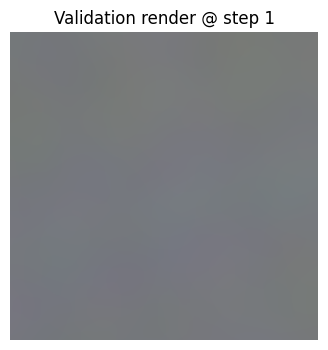

step    50 | train loss = 0.063209
step   100 | train loss = 0.050547
step   150 | train loss = 0.029788
step   200 | train loss = 0.019885
step   250 | train loss = 0.011707
step   300 | train loss = 0.011526
step   350 | train loss = 0.010279
step   400 | train loss = 0.009945
step   450 | train loss = 0.008249
step   500 | train loss = 0.008575
[val @ step 500] mean PSNR = 21.47 dB


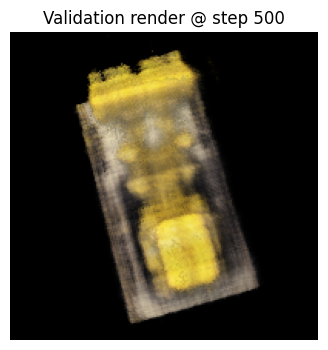

step   550 | train loss = 0.007305
step   600 | train loss = 0.007361
step   650 | train loss = 0.007912
step   700 | train loss = 0.006430
step   750 | train loss = 0.007304
step   800 | train loss = 0.006829
step   850 | train loss = 0.006308
step   900 | train loss = 0.006009
step   950 | train loss = 0.005901
step  1000 | train loss = 0.005446
[val @ step 1000] mean PSNR = 23.22 dB


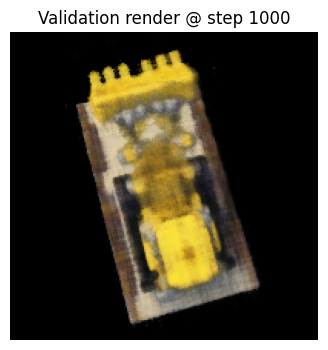

step  1050 | train loss = 0.005179
step  1100 | train loss = 0.005118
step  1150 | train loss = 0.006029
step  1200 | train loss = 0.004959
step  1250 | train loss = 0.004451
step  1300 | train loss = 0.005331
step  1350 | train loss = 0.004463
step  1400 | train loss = 0.005138
step  1450 | train loss = 0.004430
step  1500 | train loss = 0.005215
[val @ step 1500] mean PSNR = 24.26 dB


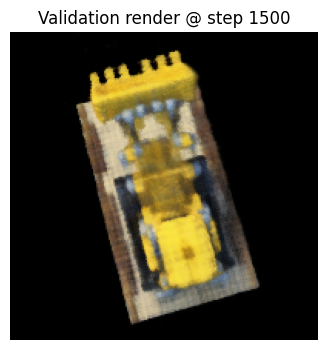

step  1550 | train loss = 0.004930
step  1600 | train loss = 0.004569
step  1650 | train loss = 0.004335
step  1700 | train loss = 0.004368
step  1750 | train loss = 0.005173
step  1800 | train loss = 0.003974
step  1850 | train loss = 0.004269
step  1900 | train loss = 0.004260
step  1950 | train loss = 0.004166
step  2000 | train loss = 0.004223
[val @ step 2000] mean PSNR = 24.80 dB


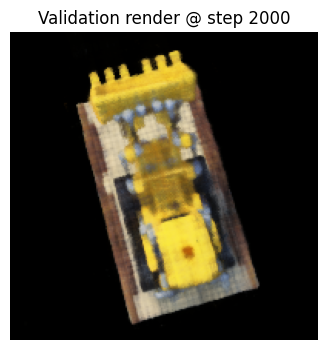

step  2050 | train loss = 0.003796
step  2100 | train loss = 0.004097
step  2150 | train loss = 0.003886
step  2200 | train loss = 0.004116
step  2250 | train loss = 0.003697
step  2300 | train loss = 0.004182
step  2350 | train loss = 0.003763
step  2400 | train loss = 0.003496
step  2450 | train loss = 0.003957
step  2500 | train loss = 0.004055
[val @ step 2500] mean PSNR = 25.28 dB


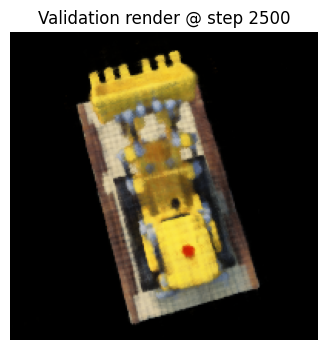

step  2550 | train loss = 0.003798
step  2600 | train loss = 0.003889
step  2650 | train loss = 0.003733
step  2700 | train loss = 0.003827
step  2750 | train loss = 0.004004
step  2800 | train loss = 0.003733
step  2850 | train loss = 0.003543
step  2900 | train loss = 0.003554
step  2950 | train loss = 0.003705
step  3000 | train loss = 0.003793
[val @ step 3000] mean PSNR = 25.46 dB


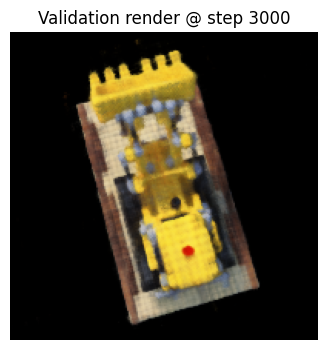

In [ ]:
# training loop
for step in range(1, num_steps + 1):
    rays_o, rays_d, target_rgb = train_rays.sample_rays(batch_size)

    pred_rgb = render_ray_batch(
        model,
        rays_o,
        rays_d,
        near=near,
        far=far,
        n_samples=n_samples,
        perturb=True,
    )

    loss = F.mse_loss(pred_rgb, target_rgb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    history["train_loss"].append(loss.item())

    if step % print_every == 0:
        print(f"step {step:5d} | train loss = {loss.item():.6f}")

    if step % validate_every == 0 or step == 1 or step == num_steps:
        mean_psnr, preview, per_image_psnr = run_validation(
            model,
            val_rays,
            images_val,
            near=near,
            far=far,
            n_samples=n_samples,
            chunk_size=8192,
        )

        history["val_psnr"].append(mean_psnr)
        history["val_step"].append(step)

        print(f"[val @ step {step}] mean PSNR = {mean_psnr:.2f} dB")

        plt.figure(figsize=(4, 4))
        plt.imshow(preview)
        plt.title(f"Validation render @ step {step}")
        plt.axis("off")
        plt.savefig(
            save_dir / f"val_render_{step:06d}.png", dpi=200, bbox_inches="tight"
        )
        plt.show()

        torch.save(
            {
                "step": step,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "history": history,
            },
            save_dir / f"checkpoint_{step:06d}.pt",
        )

        if mean_psnr > best_val_psnr:
            best_val_psnr = mean_psnr
            torch.save(model.state_dict(), save_dir / "best_model.pt")

        np.save(
            save_dir / "train_loss.npy",
            np.array(history["train_loss"], dtype=np.float32),
        )
        np.save(
            save_dir / "val_psnr.npy", np.array(history["val_psnr"], dtype=np.float32)
        )
        np.save(
            save_dir / "val_step.npy", np.array(history["val_step"], dtype=np.int32)
        )

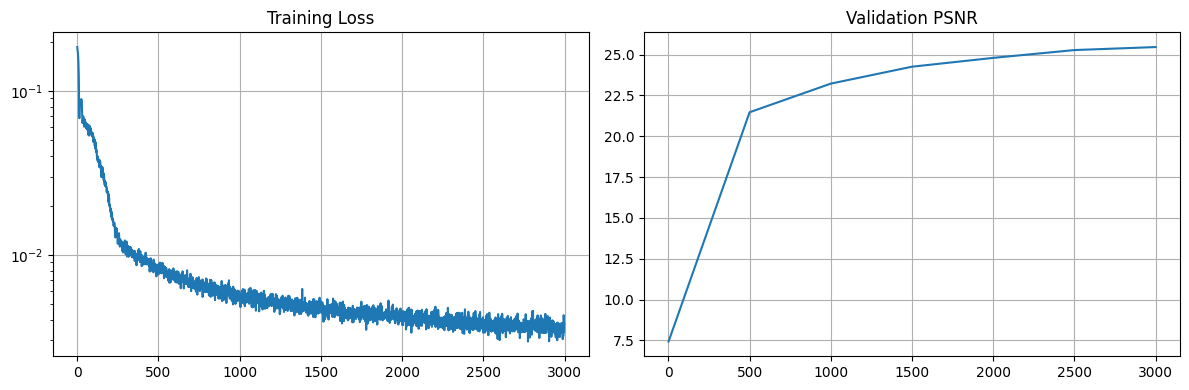

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"])
plt.title("Training Loss")
plt.yscale("log")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history["val_step"], history["val_psnr"])
plt.title("Validation PSNR")
plt.grid(True)

plt.tight_layout()
plt.savefig(save_dir / "training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

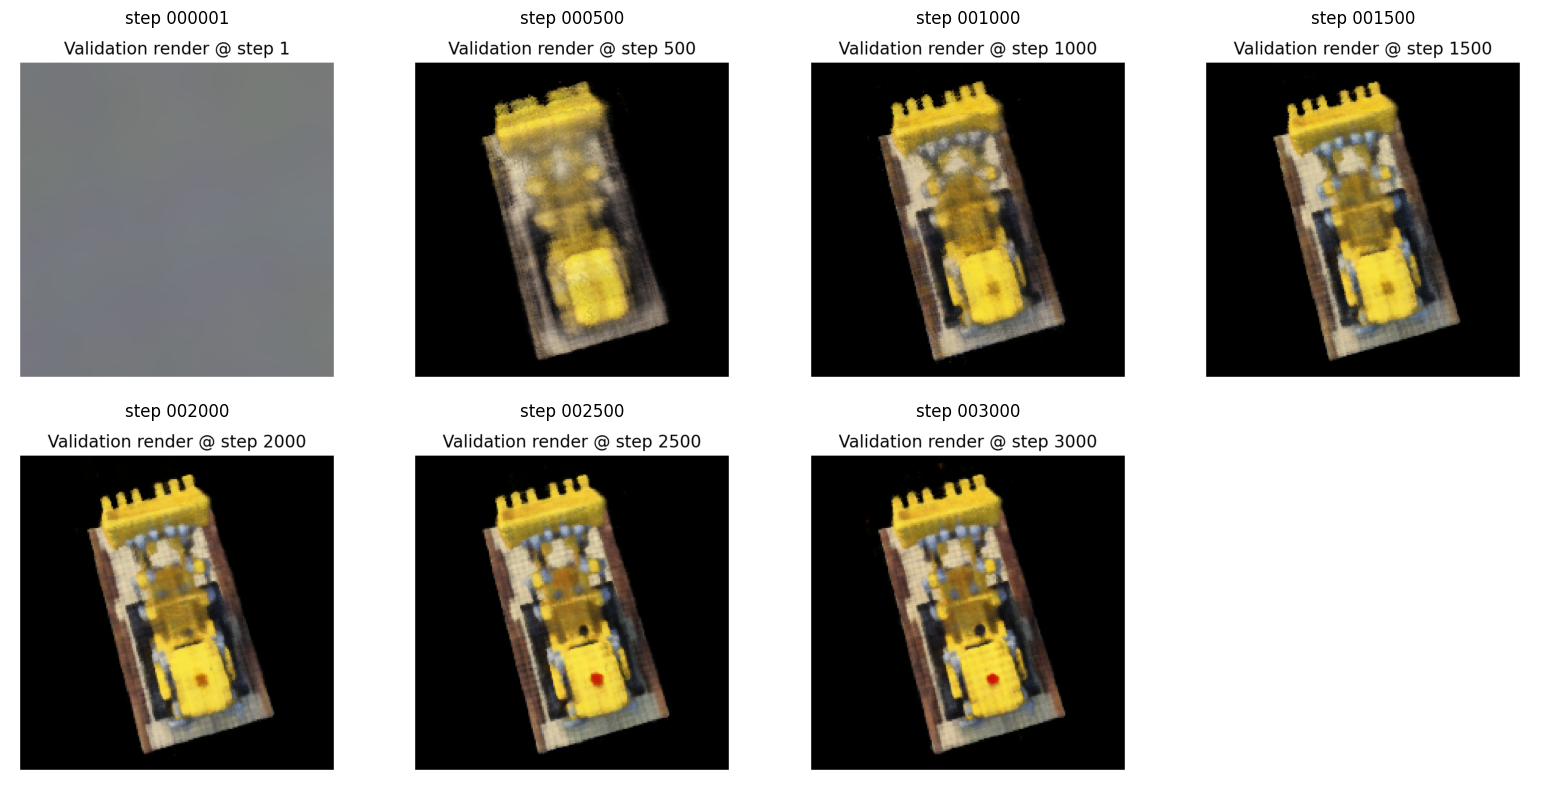

In [24]:
cols = 4
rows = math.ceil(len(image_paths) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten() if len(image_paths) > 1 else [axes]

for ax, img_path in zip(axes, image_paths):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(img_path.stem.replace("val_render_", "step "))
    ax.axis("off")

for ax in axes[len(image_paths) :]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(save_dir / "val_render_grid.png", dpi=200, bbox_inches="tight")
plt.show()